**Project Description**


Using logistic Regession to predict 6-figure earning emloyees.

In [1]:
!pip install kagglehub

In [33]:
import kagglehub
import pandas as pd

# Downloading dataset(the same one as the LinearRegression models)
path = kagglehub.dataset_download("wardabilal/salary-prediction-dataset")
print("Path to dataset files:", path)

df = pd.read_csv(path + "/Salary_Data.csv")
df.head()

Using Colab cache for faster access to the 'salary-prediction-dataset' dataset.
Path to dataset files: /kaggle/input/salary-prediction-dataset


,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


In [23]:
df.describe()

,Age,Years of Experience,Salary
count,6702.000000,6701.000000,6699.000000
mean,33.620859,8.094687,115326.964771
std,7.614633,6.059003,52786.183911
min,21.000000,0.000000,350.000000
25%,28.000000,3.000000,70000.000000
50%,32.000000,7.000000,115000.000000
75%,38.000000,12.000000,160000.000000
max,62.000000,34.000000,250000.000000


**Data Cleaning**

In [34]:
print(df.isnull().sum())

df = df.dropna()

print(df.dtypes)

Age                    2
Gender                 2
Education Level        3
Job Title              2
Years of Experience    3
Salary                 5
dtype: int64
Age                    float64
Gender                  object
Education Level         object
Job Title               object
Years of Experience    float64
Salary                 float64
dtype: object


In [25]:
df.shape

(6698, 6)

In [35]:
#Creating our binary target variable: HighSalary

df['HighSalary'] = (df['Salary'] > 100000).astype(int)

df = df.drop(columns=['Salary'])

df['HighSalary'].value_counts()


,count
HighSalary,
1,3772
0,2926


**Data Preprocessing**

In [36]:
X = df.drop(columns=['HighSalary'])
y = df['HighSalary']

In [38]:
#Encoding categorical variables
X = pd.get_dummies(X, drop_first=True)

In [39]:
#Normalizing continuous variables
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
num_cols = X.select_dtypes(include=['float64', 'int64']).columns
X[num_cols] = scaler.fit_transform(X[num_cols])

In [40]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

**Model training**

Adding class_weight=“balanced” to manage class imbalance

In [41]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
model.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

**Model evaluation using Cross-validation**

In [43]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)
from sklearn.model_selection import cross_val_score
import numpy as np

#Performance on Test Set (using the imbalanced-aware model)
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1] # Get probabilities for class 1 (HighSalary)

print("--- Performance on Test Set ---")

#Focus on the Classification Report and ROC AUC Score:
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"\nROC AUC Score: {roc_auc:.4f}")


#Robust Cross-Validation Assessment
print("\n--- Cross-Validation Assessment (k=5) ---")

#IMPROVEMENT: Use F1-score or ROC AUC (not Accuracy) for cross-validation scoring
#since F1 is better for imbalanced data.
cv_scores = cross_val_score(model, X, y, cv=5, scoring='f1')

print(f"5-Fold Cross-Validation F1-Scores: {cv_scores}")
print(f"Average Cross-Validation F1-Score: {np.mean(cv_scores):.4f} (+/- {np.std(cv_scores):.4f})")

--- Performance on Test Set ---

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.93      0.94       602
           1       0.95      0.96      0.95       738

    accuracy                           0.95      1340
   macro avg       0.95      0.95      0.95      1340
weighted avg       0.95      0.95      0.95      1340


Confusion Matrix:
[[561  41]
 [ 28 710]]

ROC AUC Score: 0.9885

--- Cross-Validation Assessment (k=5) ---
5-Fold Cross-Validation F1-Scores: [0.84723149 0.9160105  0.92923899 0.88984263 0.94422311]
Average Cross-Validation F1-Score: 0.9053 (+/- 0.0341)


**Visualizations**

--- Numerical Evaluation Metrics ---

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.93      0.94       602
           1       0.95      0.96      0.95       738

    accuracy                           0.95      1340
   macro avg       0.95      0.95      0.95      1340
weighted avg       0.95      0.95      0.95      1340


ROC AUC Score: 0.9885

--- Cross-Validation F1-Scores ---
Average F1-Score (5-Fold CV): 0.9053 (+/- 0.0341)


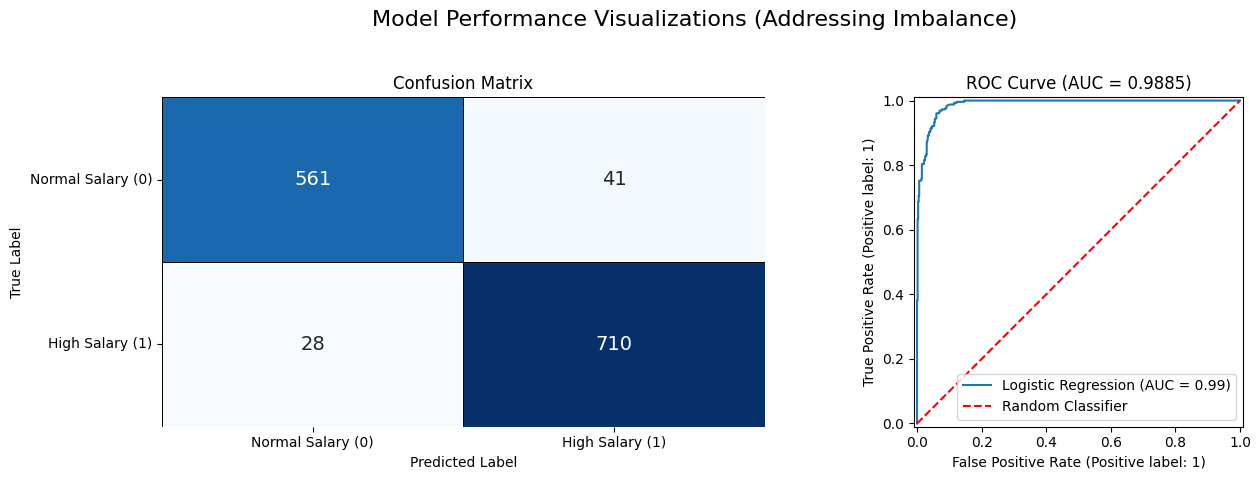

In [44]:
import numpy as np
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    RocCurveDisplay
)
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt
import seaborn as sns

# --- Predictions ---
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

# --- Print Numerical Metrics ---
print("--- Numerical Evaluation Metrics ---")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"\nROC AUC Score: {roc_auc:.4f}")

# ---Cross-Validation Assessment ---
cv_scores = cross_val_score(model, X, y, cv=5, scoring='f1')
print("\n--- Cross-Validation F1-Scores ---")
print(f"Average F1-Score (5-Fold CV): {np.mean(cv_scores):.4f} (+/- {np.std(cv_scores):.4f})")

# ---Visualizations ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plt.suptitle('Model Performance Visualizations (Addressing Imbalance)', fontsize=16)

#Confusion Matrix Heatmap
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(
    cm,
    annot=True,
    fmt='d', # 'd' formats the numbers as integers
    cmap='Blues',
    cbar=False,
    ax=axes[0],
    linewidths=0.5,
    linecolor='black',
    annot_kws={"size": 14}
)
axes[0].set_title('Confusion Matrix', fontsize=12)
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')
axes[0].set_xticklabels(['Normal Salary (0)', 'High Salary (1)'])
axes[0].set_yticklabels(['Normal Salary (0)', 'High Salary (1)'], rotation=0)

#ROC Curve Plot
RocCurveDisplay.from_estimator(
    model,
    X_test,
    y_test,
    ax=axes[1],
    name='Logistic Regression'
)
axes[1].plot([0, 1], [0, 1], 'r--', label='Random Classifier') # Diagonal line for comparison
axes[1].set_title(f'ROC Curve (AUC = {roc_auc:.4f})', fontsize=12)
axes[1].legend(loc="lower right")

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [51]:
# Extracting Coefficients
# model.coef_[0] is used for binary classification to get the coefficients for class 1
coefficients = model.coef_[0]

# Creating a DataFrame for Interpretation
coeff_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient (Log-Odds)': coefficients
})

# Calculating Odds Ratio (e^coefficient)
# An Odds Ratio > 1 means the feature increases the odds of a six-figure salary.
coeff_df['Odds Ratio (e^Coeff)'] = np.exp(coeff_df['Coefficient (Log-Odds)'])


coeff_df_sorted = coeff_df.sort_values(by='Coefficient (Log-Odds)', ascending=False).head(10)

coeff_df_sorted1 = coeff_df.sort_values(by='Coefficient (Log-Odds)', ascending=False).tail(10)

print(coeff_df_sorted)
print(coeff_df_sorted1)


                                 Feature  Coefficient (Log-Odds)  \
1                    Years of Experience                6.197498   
115            Job Title_Product Manager                4.313749   
53         Job Title_Full Stack Engineer                3.967253   
29              Job Title_Data Scientist                3.875857   
185  Job Title_Software Engineer Manager                3.782049   
52         Job Title_Front end Developer                2.998326   
167    Job Title_Senior Project Engineer                2.838796   
118            Job Title_Project Manager                2.691806   
184          Job Title_Software Engineer                2.484167   
27                Job Title_Data Analyst                2.399028   

     Odds Ratio (e^Coeff)  
1              491.517580  
115             74.720055  
53              52.839162  
29              48.223999  
185             43.905893  
52              20.051951  
167             17.095168  
118             14.758301  

**Key Interpretations**



*   ROC AUC Score 0.94: It means the model has a 93.89% chance of correctly distinguishing between a six-figure earner and a non-six-figure earner.
*   High F1: This score shows the model has great balance between Precision  and Recall.
*   Experience is the most consistent predictor. Every additional year of experience increases the odds of earning a six-figure salary. This is the highest individual coefficient, confirming its crucial role.
